# QoS-weighted QFL aggregation (Linear vs Circular) — Notebook

This notebook wraps the fixed script `pasted_qos_updated_fixed.py`.

The previous error (`AttributeError: 'FLConfig' object has no attribute 'use_qos_weights'`)
occurred because QoS fields were outside the `FLConfig` dataclass. This notebook fixes that,
so you can toggle QoS-weighted aggregation ablations.

## Ablations
- Baseline: `use_qos_weights=False`
- Fidelity only: `use_qos_weights=True, qos_alpha=1, qos_gamma=0, qos_delta=0`
- Latency only: `use_qos_weights=True, qos_alpha=0, qos_gamma=1, qos_delta=0`
- Instability only: `use_qos_weights=True, qos_alpha=0, qos_gamma=0, qos_delta=1`
- All signals: `use_qos_weights=True, qos_alpha=1, qos_gamma=1, qos_delta=1`


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install "qiskit>=1.1" qiskit-aer qiskit-algorithms "qiskit-machine-learning>=0.7" qiskit-ibm-runtime \
                 scikit-learn pandas matplotlib numpy torch torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 66.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 113.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.1/263.1 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 378.5/378.5 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 61.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 10.2 MB/s eta 0:00:00


In [ ]:
# (Optional) quick sanity check that FLConfig has QoS fields
# Run this cell after executing the main script cell below if you want to confirm.


In [ ]:
import json
import numpy as np
import pandas as pd
from pathlib import Path

# Adjust if your Drive base differs
BASE = Path("/content/drive/MyDrive/AutopickV2/QFL_folder/newQosMotivation/Seeds")

TAIL_K = 20
SAFE_Q = 0.25

ACC = "val_acc"
TEST = "test_acc"
RISK = "risk_t"
GEOM = "geom_err_deg"

def auc_norm(df, col):
    x = df["round"].to_numpy(float)
    y = df[col].to_numpy(float)
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    if len(x) < 2:
        return np.nan
    idx = np.argsort(x)
    x, y = x[idx], y[idx]
    auc = np.trapz(y, x)
    denom = x.max() - x.min()
    return float(auc / denom) if denom > 0 else np.nan

def method_label(meta):
    # Preferred: use meta flags so it works even if filenames change
    if bool(meta.get("use_qos_weights", False)):
        return "QoS"
    mode = meta.get("agg_mode", "")
    if mode == "linear_weighted":
        return "Linear"
    if mode == "circular_weighted":
        return "Circular"
    if mode == "auto_pick":
        return f"AutoPick:{meta.get('autopick_policy','?')}"
    return str(mode)

# ---- load all runs ----
runs = []
for meta_path in BASE.rglob("run_metadata.json"):
    outdir = meta_path.parent
    meta = json.loads(meta_path.read_text())

    # find the round-metrics csv saved by rounds_csv_path(...)
    csvs = sorted(outdir.glob("round_metrics_*_clients*_rounds*.csv"))
    if not csvs:
        continue
    df = pd.read_csv(csvs[0]).sort_values("round")
    df = df[df["round"] >= 1].reset_index(drop=True)

    runs.append((meta, df))

if not runs:
    raise RuntimeError(f"No runs found under: {BASE}")

# ---- compute pooled safe threshold per (dataset, partition, alpha, noise, stress) ----
pool_rows = []
for meta, df in runs:
    if RISK in df.columns:
        pool_rows.append({
            "dataset": meta.get("dataset"),
            "partition": meta.get("partition"),
            "alpha": meta.get("dirichlet_alpha", None),
            "noise": meta.get("local_init_noise", None),
            "stress": meta.get("angle_stress", None),
            "risk": df[RISK].to_numpy(float)
        })

pool_expanded = []
for r in pool_rows:
    for v in r["risk"]:
        if np.isfinite(v):
            pool_expanded.append({k: r[k] for k in ["dataset","partition","alpha","noise","stress"]} | {"risk": v})
pool_expanded = pd.DataFrame(pool_expanded)

thr_map = (
    pool_expanded
    .groupby(["dataset","partition","alpha","noise","stress"])["risk"]
    .quantile(SAFE_Q)
    .to_dict()
)

# ---- per-seed summaries ----
rows = []
for meta, df in runs:
    dataset  = meta.get("dataset")
    part     = meta.get("partition")
    alpha    = meta.get("dirichlet_alpha", None)
    noise    = meta.get("local_init_noise", None)
    stress   = meta.get("angle_stress", None)
    seed     = meta.get("seed")
    method   = method_label(meta)

    key = (dataset, part, alpha, noise, stress)
    thr = float(thr_map.get(key, np.nan))

    row = {
        "dataset": dataset,
        "partition": part,
        "alpha": alpha,
        "noise": noise,
        "stress": stress,
        "seed": seed,
        "method": method,
        "rounds": len(df),
        "risk_thr_q": thr,
    }

    if ACC in df.columns:
        row["val_best"] = float(df[ACC].max())
        row["val_tail"] = float(df[ACC].tail(TAIL_K).mean())
        row["val_auc_norm"] = auc_norm(df, ACC)

    if TEST in df.columns:
        row["test_best"] = float(df[TEST].max())
        row["test_tail"] = float(df[TEST].tail(TAIL_K).mean())
        row["test_auc_norm"] = auc_norm(df, TEST)

    if RISK in df.columns:
        row["risk_mean"] = float(df[RISK].mean())
        row["risk_max"]  = float(df[RISK].max())
        row["risk_auc_norm"] = auc_norm(df, RISK)
        row[f"safe_frac_q{SAFE_Q}"] = float((df[RISK] < thr).mean()) if np.isfinite(thr) else np.nan

    if GEOM in df.columns:
        row["geom_mean"] = float(df[GEOM].mean())
        row["geom_max"]  = float(df[GEOM].max())
        row["geom_auc_norm"] = auc_norm(df, GEOM)

    rows.append(row)

per_seed = pd.DataFrame(rows)

# ---- aggregate across seeds per scenario + method ----
def mean_std_worst(g, col):
    return pd.Series({
        f"{col}_mean": g[col].mean(),
        f"{col}_std":  g[col].std(ddof=1),
        f"{col}_worst": g[col].min(),   # worst-case robustness (min across seeds)
    })

agg_cols = ["val_best","val_tail","test_best","test_tail","risk_mean","geom_mean",f"safe_frac_q{SAFE_Q}"]

out = []
group_keys = ["dataset","partition","alpha","noise","stress","method"]
for keys, g in per_seed.groupby(group_keys):
    row = dict(zip(group_keys, keys))
    row["n_seeds"] = g["seed"].nunique()
    for c in agg_cols:
        if c in g.columns:
            row.update(mean_std_worst(g, c).to_dict())
    out.append(row)

summary = pd.DataFrame(out).sort_values(["dataset","partition","alpha","noise","stress","method"])

display(per_seed)
display(summary)

per_seed.to_csv("multiseed_per_seed_All.csv", index=False)
summary.to_csv("multiseed_summary_All.csv", index=False)

print("Saved: multiseed_per_seed_circ.csv, multiseed_summary_circ.csv")
print("\nLaTeX:\n")
print(summary.round(4).to_latex(index=False))

/tmp/ipython-input-2311856341.py:26: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(y, x)


,dataset,partition,alpha,noise,stress,seed,method,rounds,risk_thr_q,val_best,...,test_best,test_tail,test_auc_norm,risk_mean,risk_max,risk_auc_norm,safe_frac_q0.25,geom_mean,geom_max,geom_auc_norm
0,clinical,dirichlet,0.1,0.1,False,0,Linear,200,0.033256,0.777778,...,0.600000,0.494211,0.488971,0.043225,0.099119,0.043238,0.195000,0.993174,2.192476,0.994609
1,clinical,dirichlet,0.1,0.1,False,1,Linear,200,0.033256,0.722222,...,0.621053,0.462632,0.483893,0.071119,0.272858,0.071148,0.000000,1.328583,12.183835,1.330101
2,clinical,dirichlet,0.1,0.1,False,2,Linear,200,0.033256,0.777778,...,0.610526,0.464211,0.488998,0.033823,0.104023,0.033839,0.660000,1.139832,4.091892,1.140015
3,clinical,dirichlet,0.1,0.1,False,3,Linear,200,0.033256,0.722222,...,0.600000,0.507895,0.489527,0.064624,0.226602,0.064584,0.000000,1.104397,6.203201,1.104648
4,clinical,dirichlet,0.1,0.1,False,4,Linear,200,0.033256,0.833333,...,0.631579,0.477368,0.498228,0.068365,0.248625,0.068394,0.005000,1.190580,8.223249,1.189502
5,clinical,dirichlet,0.1,0.1,False,4,Circular,200,0.033256,0.722222,...,0.652632,0.492632,0.511161,0.066334,0.240849,0.066311,0.005000,1.171853,7.143869,1.171204
6,clinical,dirichlet,0.1,0.1,False,3,Circular,200,0.033256,0.722222,...,0.610526,0.463158,0.485163,0.065754,0.246603,0.065735,0.000000,1.074870,13.518849,1.074129
7,clinical,dirichlet,0.1,0.1,False,2,Circular,200,0.033256,0.833333,...,0.600000,0.493684,0.486300,0.034681,0.135602,0.034696,0.670000,1.109473,5.174889,1.109006
8,clinical,dirichlet,0.1,0.1,False,1,Circular,200,0.033256,0.777778,...,0.642105,0.496842,0.493547,0.068498,0.304876,0.068449,0.010000,1.225453,11.261887,1.226930
9,clinical,dirichlet,0.1,0.1,False,0,Circular,200,0.033256,0.722222,...,0.589474,0.478421,0.479080,0.044302,0.114401,0.044231,0.205000,1.063863,3.850083,1.061554


,dataset,partition,alpha,noise,stress,method,n_seeds,val_best_mean,val_best_std,val_best_worst,...,test_tail_worst,risk_mean_mean,risk_mean_std,risk_mean_worst,geom_mean_mean,geom_mean_std,geom_mean_worst,safe_frac_q0.25_mean,safe_frac_q0.25_std,safe_frac_q0.25_worst
0,biomarker_arcene,dirichlet,0.1,0.1,False,Circular,5,0.742857,0.104328,0.571429,...,0.471667,0.542416,0.050082,0.466811,30.972590,8.306632,17.489284,0.044000,0.041743,0.000000
1,biomarker_arcene,dirichlet,0.1,0.1,False,Linear,5,0.857143,0.058321,0.809524,...,0.458333,0.550779,0.047968,0.476960,32.192883,8.887872,17.440469,0.035632,0.027157,0.010000
2,biomarker_arcene,dirichlet,0.1,0.1,False,QoS,5,0.676190,0.062088,0.619048,...,0.458333,0.237858,0.033838,0.194793,1.244688,0.892689,0.015367,0.611000,0.147792,0.360000
3,biomarker_leukemia,dirichlet,0.1,0.1,False,Circular,5,0.850000,0.104583,0.750000,...,0.434091,0.308855,0.056156,0.216107,13.168064,2.964586,8.897461,0.222000,0.143466,0.140000
4,biomarker_leukemia,dirichlet,0.1,0.1,False,Linear,5,0.875000,0.000000,0.875000,...,0.431818,0.398612,0.021380,0.374320,19.268327,3.081600,15.097796,0.098000,0.009083,0.090000
5,biomarker_leukemia,dirichlet,0.1,0.1,False,QoS,5,0.700000,0.068465,0.625000,...,0.306818,0.155052,0.053620,0.080783,1.369200,1.349916,0.132713,0.430000,0.222823,0.265000
6,breast_cancer,dirichlet,0.1,0.1,False,Circular,4,0.666667,0.049065,0.616667,...,0.492982,0.349878,0.098890,0.247327,13.694459,9.428997,0.085598,0.126979,0.096999,0.010000
7,breast_cancer,dirichlet,0.1,0.1,False,Linear,5,0.690000,0.009129,0.683333,...,0.493860,0.401334,0.109231,0.310043,16.641293,7.868162,6.027368,0.107000,0.120706,0.000000
8,breast_cancer,dirichlet,0.1,0.1,False,QoS,5,0.611111,0.077220,0.500000,...,0.497953,0.192038,0.022131,0.172275,1.080011,1.619964,0.015359,0.441756,0.153245,0.150538
9,clinical,dirichlet,0.1,0.1,False,Circular,5,0.755556,0.049690,0.722222,...,0.463158,0.055914,0.015407,0.034681,1.129103,0.068362,1.063863,0.178000,0.288370,0.000000


Saved: multiseed_per_seed_circ.csv, multiseed_summary_circ.csv

LaTeX:

\begin{tabular}{llrrrlrrrrrrrrrrrrrrrrrrrrrr}
\toprule
dataset & partition & alpha & noise & stress & method & n_seeds & val_best_mean & val_best_std & val_best_worst & val_tail_mean & val_tail_std & val_tail_worst & test_best_mean & test_best_std & test_best_worst & test_tail_mean & test_tail_std & test_tail_worst & risk_mean_mean & risk_mean_std & risk_mean_worst & geom_mean_mean & geom_mean_std & geom_mean_worst & safe_frac_q0.25_mean & safe_frac_q0.25_std & safe_frac_q0.25_worst \\
\midrule
biomarker_arcene & dirichlet & 0.100000 & 0.100000 & False & Circular & 5 & 0.742900 & 0.104300 & 0.571400 & 0.504100 & 0.020800 & 0.473800 & 0.643300 & 0.049400 & 0.566700 & 0.494300 & 0.014600 & 0.471700 & 0.542400 & 0.050100 & 0.466800 & 30.972600 & 8.306600 & 17.489300 & 0.044000 & 0.041700 & 0.000000 \\
biomarker_arcene & dirichlet & 0.100000 & 0.100000 & False & Linear & 5 & 0.857100 & 0.058300 & 0.809500 & 0.513800 & 

In [ ]:
import json
import numpy as np
import pandas as pd
from pathlib import Path

# =========================
# CONFIG
# =========================
# Change this to your root folder that contains subfolders with run_metadata.json
BASE = Path("/content/drive/MyDrive/AutopickV2/QFL_folder/newQosMotivation/Seeds")

TAIL_K = 20          # tail window (last K rounds)
SAFE_Q = 0.25        # pooled risk threshold quantile
BUDGETS = [50, 100, 200]  # accuracy-at-round budgets (works with T=200)

# Column names in your round-wise CSV
ROUND = "round"
ACC_VAL = "val_acc"
ACC_TEST = "test_acc"
ACC_TRAIN = "train_acc"
RISK = "risk_t"
GEOM = "geom_err_deg"

# =========================
# HELPERS
# =========================
def auc_norm(df: pd.DataFrame, col: str, xcol: str = ROUND) -> float:
    """Normalized trapezoidal AUC over rounds: AUC / (x_max - x_min)."""
    if col not in df.columns or xcol not in df.columns:
        return np.nan
    x = df[xcol].to_numpy(float)
    y = df[col].to_numpy(float)
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    if len(x) < 2:
        return np.nan
    idx = np.argsort(x)
    x, y = x[idx], y[idx]
    auc = np.trapz(y, x)
    denom = x.max() - x.min()
    return float(auc / denom) if denom > 0 else np.nan

def acc_at_budget(df: pd.DataFrame, col: str, b: int, xcol: str = ROUND) -> float:
    """Accuracy at the nearest available round <= budget b (robust to missing rounds)."""
    if col not in df.columns or xcol not in df.columns:
        return np.nan
    d = df[[xcol, col]].dropna()
    d = d[np.isfinite(d[xcol].to_numpy(float))]
    if d.empty:
        return np.nan
    d = d.sort_values(xcol)
    d = d[d[xcol] <= b]
    if d.empty:
        return np.nan
    return float(d.iloc[-1][col])

def iqr(x: np.ndarray) -> float:
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan
    return float(np.percentile(x, 75) - np.percentile(x, 25))

def method_label(meta: dict) -> str:
    """Prefer meta flags so labeling doesn't depend on filenames."""
    if bool(meta.get("use_qos_weights", False)):
        return "QoS-aware"
    mode = str(meta.get("agg_mode", "")).strip()
    if mode == "linear_weighted":
        return "Linear"
    if mode == "circular_weighted":
        return "Circular"
    if mode == "auto_pick":
        return f"AutoPick:{meta.get('autopick_policy','?')}"
    return mode if mode else "Unknown"

def scenario_key(meta: dict):
    """Group keys for pooled thresholds and seed aggregation."""
    return (
        meta.get("dataset"),
        meta.get("partition"),
        meta.get("dirichlet_alpha", None),
        meta.get("local_init_noise", None),
        meta.get("angle_stress", None),
    )

def find_round_csv(outdir: Path) -> Path | None:
    """Find a round-wise metrics CSV in the run folder."""
    candidates = sorted(outdir.glob("round_metrics_*_clients*_rounds*.csv"))
    if candidates:
        return candidates[0]
    # fallback: any CSV with a 'round' column
    for p in sorted(outdir.glob("*.csv")):
        try:
            tmp = pd.read_csv(p, nrows=5)
            if ROUND in tmp.columns:
                return p
        except Exception:
            pass
    return None

# For "worst" across seeds: some metrics are higher-better, others lower-better.
HIGHER_BETTER = {
    "val_best", "val_tail", "val_mean", "val_auc_norm",
    "test_best", "test_tail", "test_mean", "test_auc_norm",
    "train_best", "train_tail", "train_mean", "train_auc_norm",
    "safe_frac",
    # acc@budgets will also be higher-better
}
LOWER_BETTER = {
    "risk_mean", "risk_max", "risk_auc_norm",
    "geom_mean", "geom_max", "geom_auc_norm",
    # stability (std/iqr) are lower-better if you use them as "oscillation"
    "test_std", "test_iqr", "val_std", "val_iqr", "train_std", "train_iqr",
}

def mean_std_worst(g: pd.DataFrame, col: str) -> dict:
    """Return mean, std, and worst-case across seeds for a given metric."""
    v = g[col].to_numpy(float)
    v = v[np.isfinite(v)]
    if v.size == 0:
        return {f"{col}_mean": np.nan, f"{col}_std": np.nan, f"{col}_worst": np.nan}

    out = {f"{col}_mean": float(v.mean()), f"{col}_std": float(np.std(v, ddof=1)) if v.size > 1 else 0.0}

    # worst-case definition depends on direction
    if col in HIGHER_BETTER:
        out[f"{col}_worst"] = float(v.min())
    elif col in LOWER_BETTER:
        out[f"{col}_worst"] = float(v.max())
    else:
        # default: assume higher-better (conservative)
        out[f"{col}_worst"] = float(v.min())
    return out

# =========================
# LOAD RUNS
# =========================
runs = []
for meta_path in BASE.rglob("run_metadata.json"):
    outdir = meta_path.parent
    try:
        meta = json.loads(meta_path.read_text())
    except Exception:
        continue

    csv_path = find_round_csv(outdir)
    if csv_path is None:
        continue

    df = pd.read_csv(csv_path).sort_values(ROUND)
    df = df[df[ROUND] >= 1].reset_index(drop=True)
    runs.append((meta, df, outdir, csv_path))

if not runs:
    raise RuntimeError(f"No runs found under: {BASE}")

print(f"Found {len(runs)} runs under:\n  {BASE}")

# =========================
# POOLED SAFE THRESHOLD PER SCENARIO (q_{SAFE_Q})
# =========================
pool = []
for meta, df, *_ in runs:
    if RISK in df.columns:
        key = scenario_key(meta)
        r = df[RISK].to_numpy(float)
        r = r[np.isfinite(r)]
        for v in r:
            pool.append((*key, float(v)))

pool_df = pd.DataFrame(pool, columns=["dataset","partition","alpha","noise","stress","risk"])
thr_map = (
    pool_df.groupby(["dataset","partition","alpha","noise","stress"])["risk"]
    .quantile(SAFE_Q)
    .to_dict()
)

# =========================
# PER-SEED METRICS
# =========================
rows = []
for meta, df, outdir, csv_path in runs:
    dataset, part, alpha, noise, stress = scenario_key(meta)
    seed = meta.get("seed", None)
    method = method_label(meta)
    thr = float(thr_map.get((dataset, part, alpha, noise, stress), np.nan))

    row = dict(
        dataset=dataset,
        partition=part,
        alpha=alpha,
        noise=noise,
        stress=stress,
        seed=seed,
        method=method,
        rounds=int(df[ROUND].max()) if ROUND in df.columns else len(df),
        csv=str(csv_path),
        risk_thr_q=thr,
    )

    # ---- accuracy profiles (val/test/train) ----
    def add_acc(prefix: str, col: str):
        if col not in df.columns:
            return
        y = df[col].to_numpy(float)
        y = y[np.isfinite(y)]
        if y.size == 0:
            return

        row[f"{prefix}_best"] = float(np.nanmax(df[col].to_numpy(float)))
        row[f"{prefix}_tail"] = float(df[col].tail(TAIL_K).mean())
        row[f"{prefix}_mean"] = float(df[col].mean())
        row[f"{prefix}_auc_norm"] = auc_norm(df, col)

        # oscillation / stability (optional but very useful in QFL)
        row[f"{prefix}_std"] = float(np.nanstd(df[col].to_numpy(float), ddof=0))
        row[f"{prefix}_iqr"] = iqr(df[col].to_numpy(float))

        # accuracy at budgets
        for b in BUDGETS:
            row[f"{prefix}_at_{b}"] = acc_at_budget(df, col, b)

    add_acc("val", ACC_VAL)
    add_acc("test", ACC_TEST)
    add_acc("train", ACC_TRAIN)

    # ---- risk / geom ----
    if RISK in df.columns:
        row["risk_mean"] = float(df[RISK].mean())
        row["risk_max"] = float(df[RISK].max())
        row["risk_auc_norm"] = auc_norm(df, RISK)
        row["safe_frac"] = float((df[RISK] < thr).mean()) if np.isfinite(thr) else np.nan

    if GEOM in df.columns:
        row["geom_mean"] = float(df[GEOM].mean())
        row["geom_max"] = float(df[GEOM].max())
        row["geom_auc_norm"] = auc_norm(df, GEOM)

    rows.append(row)

per_seed = pd.DataFrame(rows)

# =========================
# MULTI-SEED SUMMARY (grouped)
# =========================
group_keys = ["dataset","partition","alpha","noise","stress","method"]
summary_rows = []

# Choose which metrics you want in the final summary:
# You can add/remove freely without breaking the script.
METRICS = [
    # test accuracy profile
    "test_best","test_tail","test_mean","test_auc_norm",
    "test_at_50","test_at_100","test_at_200",
    "test_std","test_iqr",
    # validation profile (optional)
    "val_best","val_tail","val_mean","val_auc_norm",
    "val_at_50","val_at_100","val_at_200",
    "val_std","val_iqr",
    # risk/geometry
    "risk_mean","risk_max","safe_frac",
    "geom_mean","geom_max",
]

for keys, g in per_seed.groupby(group_keys, dropna=False):
    row = dict(zip(group_keys, keys))
    row["n_seeds"] = int(g["seed"].nunique()) if "seed" in g.columns else len(g)

    for c in METRICS:
        if c in g.columns:
            row.update(mean_std_worst(g, c))

    # also keep the pooled threshold used for safe_frac
    row["risk_thr_q"] = float(g["risk_thr_q"].dropna().iloc[0]) if "risk_thr_q" in g.columns and g["risk_thr_q"].notna().any() else np.nan

    summary_rows.append(row)

summary = (
    pd.DataFrame(summary_rows)
    .sort_values(["dataset","partition","alpha","noise","stress","method"])
    .reset_index(drop=True)
)

# =========================
# SAVE + LaTeX
# =========================
per_seed.to_csv("multiseed_per_seed_All_acc.csv", index=False)
summary.to_csv("multiseed_summary_All_acc.csv", index=False)

print("Saved:")
print("  multiseed_per_seed_All_acc.csv")
print("  multiseed_summary_All_acc.csv")

# Print a compact LaTeX table (you can subset columns for paper)
latex_cols = [
    "dataset","method","n_seeds",
    "test_best_mean","test_best_std","test_best_worst",
    "test_tail_mean","test_tail_std","test_tail_worst",
    "test_auc_norm_mean","test_auc_norm_std","test_auc_norm_worst",
    "safe_frac_mean","safe_frac_std","safe_frac_worst",
    "risk_mean_mean","risk_mean_std","risk_mean_worst",
    "geom_mean_mean","geom_mean_std","geom_mean_worst",
]

latex_cols = [c for c in latex_cols if c in summary.columns]
latex_table = summary[latex_cols].round(4).to_latex(index=False)

print("\nLaTeX (paste into paper):\n")
print(latex_table)

# If in Jupyter/Colab, you can display:
try:
    display(per_seed)
    display(summary)
except NameError:
    print("\nper_seed head:\n", per_seed.head())
    print("\nsummary head:\n", summary.head())


Found 60 runs under:
  /content/drive/MyDrive/AutopickV2/QFL_folder/newQosMotivation/Seeds


/tmp/ipython-input-1657541291.py:39: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(y, x)
/tmp/ipython-input-1657541291.py:39: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(y, x)
/tmp/ipython-input-1657541291.py:39: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(y, x)
/tmp/ipython-input-1657541291.py:39: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(y, x)
/tmp/ipython-input-1657541291.py:39: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(y, x)
/tmp/ipython-input-1

Saved:
  multiseed_per_seed_All_acc.csv
  multiseed_summary_All_acc.csv

LaTeX (paste into paper):

\begin{tabular}{llrrrrrrrrrrrrrrrrrrr}
\toprule
dataset & method & n_seeds & test_best_mean & test_best_std & test_best_worst & test_tail_mean & test_tail_std & test_tail_worst & test_auc_norm_mean & test_auc_norm_std & test_auc_norm_worst & safe_frac_mean & safe_frac_std & safe_frac_worst & risk_mean_mean & risk_mean_std & risk_mean_worst & geom_mean_mean & geom_mean_std & geom_mean_worst \\
\midrule
biomarker_arcene & Circular & 5 & 0.643300 & 0.049400 & 0.566700 & 0.494300 & 0.014600 & 0.471700 & 0.499200 & 0.005700 & 0.493800 & 0.044000 & 0.041700 & 0.000000 & 0.542400 & 0.050100 & 0.590800 & 30.972600 & 8.306600 & 39.102000 \\
biomarker_arcene & Linear & 5 & 0.676700 & 0.038400 & 0.616700 & 0.478300 & 0.015700 & 0.458300 & 0.496300 & 0.003200 & 0.491100 & 0.035600 & 0.027200 & 0.010000 & 0.550800 & 0.048000 & 0.601000 & 32.192900 & 8.887900 & 41.451300 \\
biomarker_arcene & QoS-awar

,dataset,partition,alpha,noise,stress,seed,method,rounds,csv,risk_thr_q,...,train_at_50,train_at_100,train_at_200,risk_mean,risk_max,risk_auc_norm,safe_frac,geom_mean,geom_max,geom_auc_norm
0,clinical,dirichlet,0.1,0.1,False,0,Linear,200,/content/drive/MyDrive/AutopickV2/QFL_folder/n...,0.033256,...,0.427083,0.510417,0.447917,0.043225,0.099119,0.043238,0.195000,0.993174,2.192476,0.994609
1,clinical,dirichlet,0.1,0.1,False,1,Linear,200,/content/drive/MyDrive/AutopickV2/QFL_folder/n...,0.033256,...,0.520833,0.479167,0.302083,0.071119,0.272858,0.071148,0.000000,1.328583,12.183835,1.330101
2,clinical,dirichlet,0.1,0.1,False,2,Linear,200,/content/drive/MyDrive/AutopickV2/QFL_folder/n...,0.033256,...,0.458333,0.395833,0.437500,0.033823,0.104023,0.033839,0.660000,1.139832,4.091892,1.140015
3,clinical,dirichlet,0.1,0.1,False,3,Linear,200,/content/drive/MyDrive/AutopickV2/QFL_folder/n...,0.033256,...,0.437500,0.437500,0.375000,0.064624,0.226602,0.064584,0.000000,1.104397,6.203201,1.104648
4,clinical,dirichlet,0.1,0.1,False,4,Linear,200,/content/drive/MyDrive/AutopickV2/QFL_folder/n...,0.033256,...,0.468750,0.395833,0.468750,0.068365,0.248625,0.068394,0.005000,1.190580,8.223249,1.189502
5,clinical,dirichlet,0.1,0.1,False,4,Circular,200,/content/drive/MyDrive/AutopickV2/QFL_folder/n...,0.033256,...,0.406250,0.437500,0.562500,0.066334,0.240849,0.066311,0.005000,1.171853,7.143869,1.171204
6,clinical,dirichlet,0.1,0.1,False,3,Circular,200,/content/drive/MyDrive/AutopickV2/QFL_folder/n...,0.033256,...,0.416667,0.406250,0.479167,0.065754,0.246603,0.065735,0.000000,1.074870,13.518849,1.074129
7,clinical,dirichlet,0.1,0.1,False,2,Circular,200,/content/drive/MyDrive/AutopickV2/QFL_folder/n...,0.033256,...,0.416667,0.395833,0.385417,0.034681,0.135602,0.034696,0.670000,1.109473,5.174889,1.109006
8,clinical,dirichlet,0.1,0.1,False,1,Circular,200,/content/drive/MyDrive/AutopickV2/QFL_folder/n...,0.033256,...,0.437500,0.531250,0.489583,0.068498,0.304876,0.068449,0.010000,1.225453,11.261887,1.226930
9,clinical,dirichlet,0.1,0.1,False,0,Circular,200,/content/drive/MyDrive/AutopickV2/QFL_folder/n...,0.033256,...,0.385417,0.437500,0.531250,0.044302,0.114401,0.044231,0.205000,1.063863,3.850083,1.061554


,dataset,partition,alpha,noise,stress,method,n_seeds,test_best_mean,test_best_std,test_best_worst,...,safe_frac_mean,safe_frac_std,safe_frac_worst,geom_mean_mean,geom_mean_std,geom_mean_worst,geom_max_mean,geom_max_std,geom_max_worst,risk_thr_q
0,biomarker_arcene,dirichlet,0.1,0.1,False,Circular,5,0.643333,0.049441,0.566667,...,0.044000,0.041743,0.000000,30.972590,8.306632,39.101951,91.878417,24.389690,125.605810,0.276637
1,biomarker_arcene,dirichlet,0.1,0.1,False,Linear,5,0.676667,0.038370,0.616667,...,0.035632,0.027157,0.010000,32.192883,8.887872,41.451309,98.451157,33.080600,143.460880,0.276637
2,biomarker_arcene,dirichlet,0.1,0.1,False,QoS-aware,5,0.630000,0.032059,0.583333,...,0.611000,0.147792,0.360000,1.244688,0.892689,2.488383,29.873010,20.729815,55.561269,0.276637
3,biomarker_leukemia,dirichlet,0.1,0.1,False,Circular,5,0.709091,0.114090,0.545455,...,0.222000,0.143466,0.140000,13.168064,2.964586,16.746609,85.058924,20.078093,116.066128,0.127408
4,biomarker_leukemia,dirichlet,0.1,0.1,False,Linear,5,0.763636,0.020328,0.727273,...,0.098000,0.009083,0.090000,19.268327,3.081600,22.018610,106.732287,26.366202,126.355556,0.127408
5,biomarker_leukemia,dirichlet,0.1,0.1,False,QoS-aware,5,0.636364,0.064282,0.590909,...,0.430000,0.222823,0.265000,1.369200,1.349916,2.969980,46.364731,23.598326,69.759919,0.127408
6,breast_cancer,dirichlet,0.1,0.1,False,Circular,4,0.578947,0.020813,0.561404,...,0.126979,0.096999,0.010000,13.694459,9.428997,20.327636,72.713761,47.731659,105.036045,0.180304
7,breast_cancer,dirichlet,0.1,0.1,False,Linear,5,0.583626,0.010461,0.573099,...,0.107000,0.120706,0.000000,16.641293,7.868162,27.665465,88.176572,39.349633,118.065834,0.180304
8,breast_cancer,dirichlet,0.1,0.1,False,QoS-aware,5,0.548733,0.014043,0.538012,...,0.441756,0.153245,0.150538,1.080011,1.619964,3.346038,26.851314,39.299045,80.521994,0.180304
9,clinical,dirichlet,0.1,0.1,False,Circular,5,0.618947,0.027247,0.589474,...,0.178000,0.288370,0.000000,1.129103,0.068362,1.225453,8.189915,4.088193,13.518849,0.033256


Compact summary

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# INPUT
# =========================
INFILE = Path("multiseed_per_seed_All_acc.csv")   # change if needed
OUTDIR = Path("plots_decision_summary")
OUTDIR.mkdir(parents=True, exist_ok=True)

METHOD_ORDER = ["Linear", "Circular", "QoS-aware"]
METHOD_MAP = {"QoS": "QoS-aware", "QoS-aware": "QoS-aware", "Linear": "Linear", "Circular": "Circular"}

# Scenario keys (your experiments)
SCEN_KEYS = ["dataset", "partition", "alpha", "noise", "stress"]

# =========================
# METRICS (choose 5–6 only)
# =========================
ACC_AUC   = "test_auc_norm"
ACC_FINAL = "test_at_200"
RISK_AUC  = "risk_auc_norm"
GEOM_AUC  = "geom_auc_norm"
SAFE_FRAC = "safe_frac"
OSC_IQR   = "test_iqr"

KEY_METRICS = [ACC_AUC, ACC_FINAL, RISK_AUC, GEOM_AUC, SAFE_FRAC, OSC_IQR]

# which direction is better
HIGHER_BETTER = {ACC_AUC, ACC_FINAL, SAFE_FRAC}
LOWER_BETTER  = {RISK_AUC, GEOM_AUC, OSC_IQR}

# =========================
# Helpers
# =========================
def sanitize(s: str) -> str:
    return "".join(ch if ch.isalnum() or ch in ("-", "_", ".", "=") else "_" for ch in str(s))

def minmax_norm(x):
    x = np.asarray(x, float)
    m = np.nanmin(x); M = np.nanmax(x)
    if not np.isfinite(m) or not np.isfinite(M) or M <= m:
        return np.zeros_like(x)
    return (x - m) / (M - m)

def norm_score(series, higher_is_better=True):
    z = minmax_norm(series.to_numpy(float))
    return z if higher_is_better else (1.0 - z)

# =========================
# Load
# =========================
df = pd.read_csv(INFILE)
df["method"] = df["method"].map(lambda x: METHOD_MAP.get(str(x), str(x)))
df = df[df["method"].isin(METHOD_ORDER)].copy()

# keep only metrics that exist
KEY_METRICS = [m for m in KEY_METRICS if m in df.columns]
if len(KEY_METRICS) < 4:
    raise RuntimeError(f"Too few key metrics found. Available columns: {df.columns.tolist()}")

# =========================
# Plot A: Accuracy vs Risk (scatter)
# =========================
def plot_tradeoff(dsub, title, outpath):
    fig, ax = plt.subplots()

    for method in METHOD_ORDER:
        d = dsub[dsub["method"] == method]
        if d.empty or ACC_AUC not in d.columns or RISK_AUC not in d.columns:
            continue
        ax.scatter(d[ACC_AUC], d[RISK_AUC], label=method, alpha=0.75)

        # method mean marker
        ax.scatter([d[ACC_AUC].mean()], [d[RISK_AUC].mean()],
                   s=120, marker="X", edgecolors="black")

    ax.set_title(title)
    ax.set_xlabel(f"{ACC_AUC} (higher better)")
    ax.set_ylabel(f"{RISK_AUC} (lower better)")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(outpath, dpi=200)
    plt.close(fig)

# =========================
# Plot B: Radar (normalized scores)
# =========================
def plot_radar(dsub, title, outpath):
    metrics = KEY_METRICS
    # compute method means
    means = dsub.groupby("method")[metrics].mean().reindex(METHOD_ORDER)

    # convert to normalized scores (0..1, higher is better for all)
    scores = pd.DataFrame(index=means.index)
    for m in metrics:
        higher = (m in HIGHER_BETTER)
        scores[m] = norm_score(means[m], higher_is_better=higher)

    # radar prep
    labels = metrics
    angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
    angles += angles[:1]

    fig = plt.figure()
    ax = plt.subplot(111, polar=True)

    for method in METHOD_ORDER:
        if method not in scores.index:
            continue
        vals = scores.loc[method, labels].to_numpy(float).tolist()
        vals += vals[:1]
        ax.plot(angles, vals, linewidth=2, label=method)
        ax.fill(angles, vals, alpha=0.10)

    ax.set_title(title, y=1.08)
    ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=8)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.10), fontsize=8)

    fig.tight_layout()
    fig.savefig(outpath, dpi=200, bbox_inches="tight")
    plt.close(fig)

# =========================
# Plot C: Heatmap (methods x metrics) normalized
# =========================
def plot_heatmap(dsub, title, outpath):
    metrics = KEY_METRICS
    means = dsub.groupby("method")[metrics].mean().reindex(METHOD_ORDER)

    # normalized score matrix (higher better)
    S = pd.DataFrame(index=means.index, columns=metrics, dtype=float)
    for m in metrics:
        higher = (m in HIGHER_BETTER)
        S[m] = norm_score(means[m], higher_is_better=higher)

    fig, ax = plt.subplots()
    im = ax.imshow(S.to_numpy(float), aspect="auto")

    ax.set_title(title)
    ax.set_yticks(np.arange(len(S.index)))
    ax.set_yticklabels(S.index)
    ax.set_xticks(np.arange(len(metrics)))
    ax.set_xticklabels(metrics, rotation=30, ha="right")

    # annotate
    for i in range(S.shape[0]):
        for j in range(S.shape[1]):
            ax.text(j, i, f"{S.iloc[i,j]:.2f}", ha="center", va="center", fontsize=8)

    fig.colorbar(im, ax=ax, fraction=0.04, pad=0.04)
    fig.tight_layout()
    fig.savefig(outpath, dpi=200)
    plt.close(fig)

# =========================
# Generate per dataset+scenario
# =========================
for keys, dsub in df.groupby(SCEN_KEYS, dropna=False):
    ds, part, a, n, st = keys
    name = f"{ds}__{part}__a{a}__n{n}__stress{st}"
    subdir = OUTDIR / sanitize(name)
    subdir.mkdir(parents=True, exist_ok=True)

    title_base = f"{ds} | {part}, a={a}, n={n}, stress={st}"

    # A: trade-off
    if (ACC_AUC in dsub.columns) and (RISK_AUC in dsub.columns):
        plot_tradeoff(dsub, f"{title_base} | trade-off (accuracy vs risk)",
                      subdir / "A_tradeoff_accuracy_vs_risk.png")

    # B: radar
    plot_radar(dsub, f"{title_base} | robustness radar (normalized)",
               subdir / "B_radar_normalized_scores.png")

    # C: heatmap
    plot_heatmap(dsub, f"{title_base} | method ranking heatmap (normalized)",
                 subdir / "C_heatmap_normalized_scores.png")

print(f"Saved decision-summary plots under: {OUTDIR.resolve()}")


Saved decision-summary plots under: /content/plots_decision_summary


/tmp/ipython-input-1234369131.py:51: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["dataset", "method"], dropna=False)


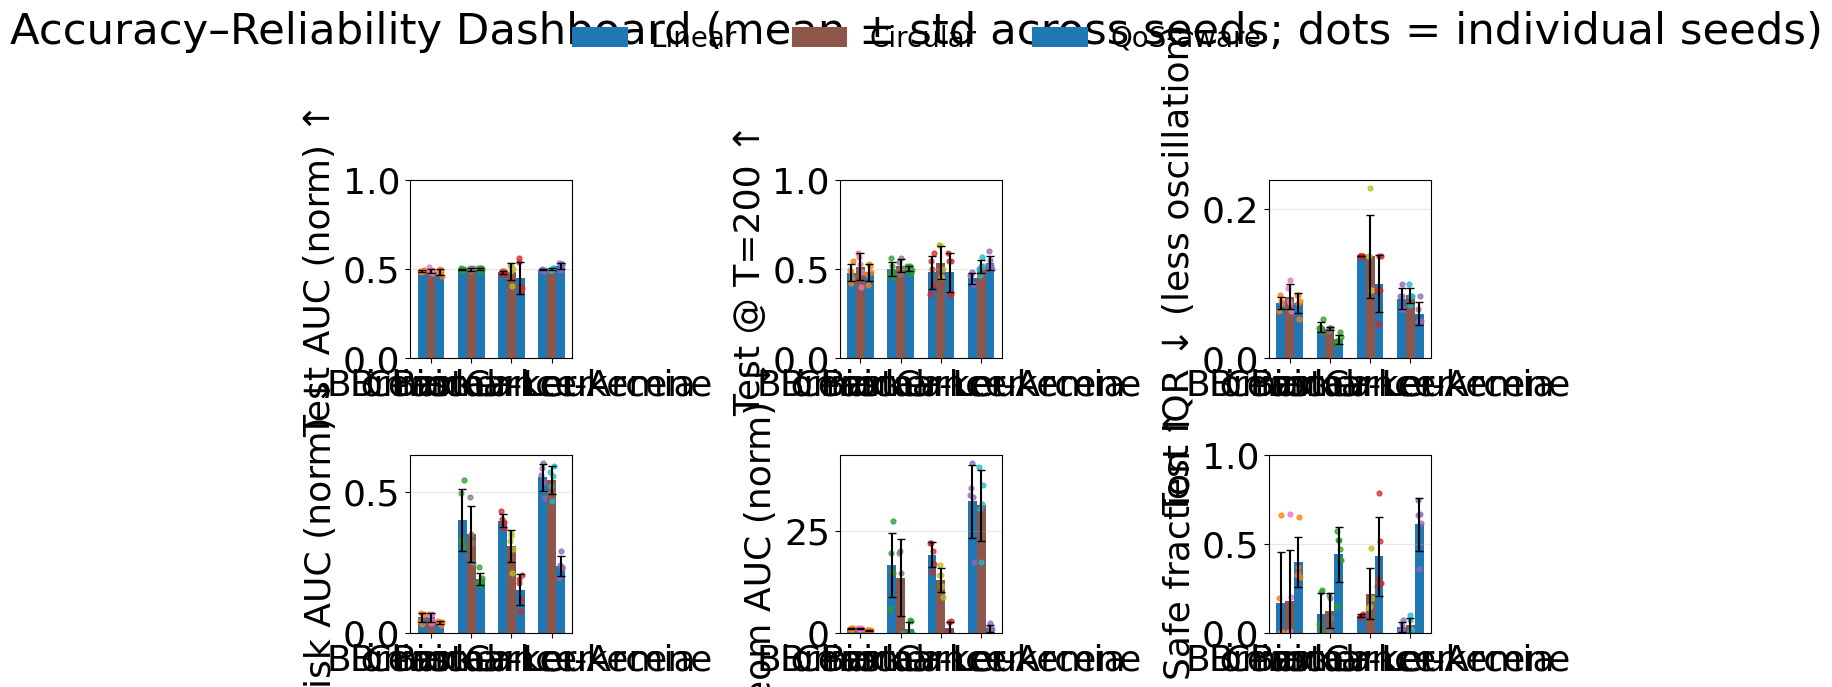

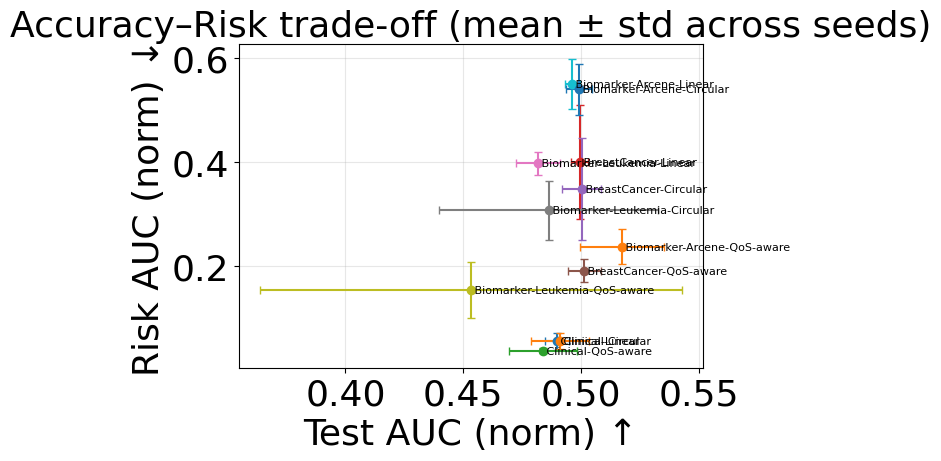

Saved plots in: /content/paper_plots


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# Input
# =========================
INFILE = Path("multiseed_per_seed_All_acc.csv")  # <- your file
OUTDIR = Path("paper_plots")
OUTDIR.mkdir(parents=True, exist_ok=True)

# Methods and datasets ordering
METHODS = ["Linear", "Circular", "QoS-aware"]
DATASET_ORDER = ["clinical", "breast_cancer", "biomarker_leukemia", "biomarker_arcene"]
DATASET_LABEL = {
    "clinical": "Clinical",
    "breast_cancer": "BreastCancer",
    "biomarker_leukemia": "Biomarker-Leukemia",
    "biomarker_arcene": "Biomarker-Arcene",
}

# Metrics to show (2x3 dashboard)
METRICS = [
    ("test_auc_norm", "Test AUC (norm) ↑"),
    ("test_at_200",   "Test @ T=200 ↑"),
    ("test_iqr",      "Test IQR ↓ (less oscillation)"),
    ("risk_auc_norm", "Risk AUC (norm) ↓"),
    ("geom_auc_norm", "Geom AUC (norm) ↓"),
    ("safe_frac",     "Safe fraction ↑"),
]

HIGHER_BETTER = {"test_auc_norm", "test_at_200", "safe_frac"}
LOWER_BETTER  = {"test_iqr", "risk_auc_norm", "geom_auc_norm"}

# =========================
# Load
# =========================
df = pd.read_csv(INFILE)
df = df[df["method"].isin(METHODS)].copy()
df["dataset"] = df["dataset"].astype(str)
df["method"]  = pd.Categorical(df["method"], categories=METHODS, ordered=True)
df["dataset"] = pd.Categorical(df["dataset"], categories=DATASET_ORDER, ordered=True)

# Some runs may be missing seeds (e.g., breast_cancer circular had 4 seeds); code is robust to that.

# =========================
# Aggregate (mean ± std across seeds) per dataset x method
# =========================
agg = (
    df.groupby(["dataset", "method"], dropna=False)
      .agg({m: ["mean", "std"] for (m, _) in METRICS})
)

# Flatten columns: ("test_auc_norm","mean") -> "test_auc_norm_mean"
agg.columns = [f"{a}_{b}" for a, b in agg.columns]
agg = agg.reset_index()

# Also keep per-seed for jitter points
per_seed = df.copy()

# =========================
# Helper for grouped bars + jitter points
# =========================
def grouped_bar_with_points(ax, metric, ylabel):
    # x positions for datasets
    datasets = [d for d in DATASET_ORDER if d in agg["dataset"].astype(str).unique()]
    x = np.arange(len(datasets), dtype=float)

    width = 0.22
    offsets = np.linspace(-width, width, len(METHODS))

    for j, method in enumerate(METHODS):
        y_mean = []
        y_std  = []
        for d in datasets:
            row = agg[(agg["dataset"].astype(str) == d) & (agg["method"].astype(str) == method)]
            if row.empty:
                y_mean.append(np.nan); y_std.append(np.nan)
            else:
                y_mean.append(float(row[f"{metric}_mean"].iloc[0]))
                y_std.append(float(row[f"{metric}_std"].iloc[0]) if np.isfinite(row[f"{metric}_std"].iloc[0]) else 0.0)

        xpos = x + offsets[j]
        ax.bar(xpos, y_mean, width=width, yerr=y_std, capsize=3, label=method)

        # jittered seed points (per-run values)
        for i, d in enumerate(datasets):
            dsub = per_seed[(per_seed["dataset"].astype(str) == d) & (per_seed["method"].astype(str) == method)]
            if metric not in dsub.columns or dsub.empty:
                continue
            yy = dsub[metric].to_numpy(float)
            # small deterministic jitter
            jitter = (np.arange(len(yy)) - (len(yy)-1)/2.0) * (width * 0.10)
            ax.scatter(np.full_like(yy, xpos[i]) + jitter, yy, s=12, alpha=0.75)

    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels([DATASET_LABEL.get(d, d) for d in datasets])
    ax.grid(True, axis="y", alpha=0.3)

# =========================
# Figure 1: 2x3 dashboard
# =========================
fig, axes = plt.subplots(2, 3, figsize=(13.5, 7.2))
axes = axes.ravel()

for k, (metric, ylabel) in enumerate(METRICS):
    ax = axes[k]
    grouped_bar_with_points(ax, metric, ylabel)

    # Optional: enforce sensible bounds
    if metric in {"test_auc_norm", "test_at_200", "safe_frac"}:
        ax.set_ylim(0.0, 1.0)
    if metric in {"risk_auc_norm", "geom_auc_norm", "test_iqr"}:
        ax.set_ylim(bottom=0.0)

# Legend only once
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False)

fig.suptitle("Accuracy–Reliability Dashboard (mean ± std across seeds; dots = individual seeds)", y=0.98)
fig.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig(OUTDIR / "Fig_dashboard_2x3.png", dpi=300)
plt.show()
plt.close(fig)

# =========================
# Figure 2 (optional): Accuracy–Risk trade-off scatter
# =========================
# point = (dataset, method) mean; error bars = std across seeds
if "test_auc_norm_mean" in agg.columns and "risk_auc_norm_mean" in agg.columns:
    fig, ax = plt.subplots(figsize=(7.2, 5.2))

    for d in DATASET_ORDER:
        dsub = agg[agg["dataset"].astype(str) == d]
        if dsub.empty:
            continue
        for m in METHODS:
            r = dsub[dsub["method"].astype(str) == m]
            if r.empty:
                continue
            x = float(r["test_auc_norm_mean"].iloc[0])
            y = float(r["risk_auc_norm_mean"].iloc[0])
            xs = float(r["test_auc_norm_std"].iloc[0]) if np.isfinite(r["test_auc_norm_std"].iloc[0]) else 0.0
            ys = float(r["risk_auc_norm_std"].iloc[0]) if np.isfinite(r["risk_auc_norm_std"].iloc[0]) else 0.0

            ax.errorbar(x, y, xerr=xs, yerr=ys, fmt="o", capsize=3)
            ax.text(x, y, f" {DATASET_LABEL.get(d,d)}-{m}", fontsize=8, va="center")

    ax.set_xlabel("Test AUC (norm) ↑")
    ax.set_ylabel("Risk AUC (norm) ↓")
    ax.grid(True, alpha=0.3)
    ax.set_title("Accuracy–Risk trade-off (mean ± std across seeds)")
    fig.tight_layout()
    fig.savefig(OUTDIR / "Fig_tradeoff_accuracy_vs_risk.png", dpi=300)
    plt.show()
    plt.close(fig)

print(f"Saved plots in: {OUTDIR.resolve()}")


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# Input / Output
# =========================
INFILE = Path("multiseed_per_seed_All_acc.csv")  # <- your file
OUTDIR = Path("/content/drive/MyDrive/AutopickV2/QFL_folder/newQosMotivation/Seeds/paper_plots_separate")
OUTDIR.mkdir(parents=True, exist_ok=True)

# =========================
# Styling (as requested)
# =========================
BASE_FONTSIZE = 26
plt.rcParams.update({
    "font.size": BASE_FONTSIZE,
    "axes.titlesize": BASE_FONTSIZE,
    "axes.labelsize": BASE_FONTSIZE,
    "xtick.labelsize": BASE_FONTSIZE,
    "ytick.labelsize": BASE_FONTSIZE,
    "legend.fontsize": max(14, BASE_FONTSIZE - 6),
})

# Methods and datasets ordering
METHODS = ["Linear", "Circular", "QoS-aware"]
METHOD_COLORS = {
    "Linear": "green",
    "Circular": "orange",
    "QoS-aware": "blue",   # QoS-circular / QoS-aware
}

DATASET_ORDER = ["clinical", "breast_cancer", "biomarker_leukemia", "biomarker_arcene"]
# Short x-axis labels to avoid overlap
DATASET_LABEL = {
    "clinical": "Clinical",
    "breast_cancer": "BCancer",
    "biomarker_leukemia": "Leukemia",
    "biomarker_arcene": "Arcene",
}

# Metrics to show (6 separate plots)
METRICS = [
    ("test_auc_norm", "Test AUC (norm) ↑"),
    ("test_at_200",   "Test @ T=200 ↑"),
    ("test_iqr",      "Test IQR ↓"),
    ("risk_auc_norm", "Risk AUC (norm) ↓"),
    ("geom_auc_norm", "Geom AUC (norm) ↓"),
    ("safe_frac",     "Safe fraction ↑"),
]

# =========================
# Load
# =========================
df = pd.read_csv(INFILE)
df = df[df["method"].isin(METHODS)].copy()
df["dataset"] = df["dataset"].astype(str)

df["method"] = pd.Categorical(df["method"], categories=METHODS, ordered=True)
df["dataset"] = pd.Categorical(df["dataset"], categories=DATASET_ORDER, ordered=True)

# =========================
# Aggregate (mean ± std across seeds) per dataset x method
# =========================
agg = (
    df.groupby(["dataset", "method"], dropna=False)
      .agg({m: ["mean", "std"] for (m, _) in METRICS if m in df.columns})
)
agg.columns = [f"{a}_{b}" for a, b in agg.columns]
agg = agg.reset_index()

per_seed = df.copy()

# =========================
# Helper: grouped bars + jittered seed points
# =========================
def grouped_bar_with_points(ax, metric, ylabel):
    datasets = [d for d in DATASET_ORDER if d in agg["dataset"].astype(str).unique()]
    x = np.arange(len(datasets), dtype=float)

    width = 0.22
    offsets = np.linspace(-width, width, len(METHODS))

    for j, method in enumerate(METHODS):
        color = METHOD_COLORS.get(method, None)

        y_mean, y_std = [], []
        for d in datasets:
            row = agg[(agg["dataset"].astype(str) == d) & (agg["method"].astype(str) == method)]
            if row.empty or f"{metric}_mean" not in row.columns:
                y_mean.append(np.nan)
                y_std.append(np.nan)
            else:
                y_mean.append(float(row[f"{metric}_mean"].iloc[0]))
                s = row[f"{metric}_std"].iloc[0]
                y_std.append(float(s) if np.isfinite(s) else 0.0)

        xpos = x + offsets[j]
        ax.bar(
            xpos, y_mean, width=width, yerr=y_std, capsize=5,
            label=method, color=color, alpha=0.85
        )

        # jittered seed points (individual runs)
        for i, d in enumerate(datasets):
            dsub = per_seed[(per_seed["dataset"].astype(str) == d) & (per_seed["method"].astype(str) == method)]
            if metric not in dsub.columns or dsub.empty:
                continue
            yy = dsub[metric].to_numpy(float)
            jitter = (np.arange(len(yy)) - (len(yy)-1)/2.0) * (width * 0.12)
            ax.scatter(
                np.full_like(yy, xpos[i]) + jitter, yy,
                s=60, alpha=0.85, color=color, edgecolors="none"
            )

    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels([DATASET_LABEL.get(d, d) for d in datasets])
    ax.grid(True, axis="y", alpha=0.25)

# =========================
# Generate 6 separate plots
# =========================
for metric, ylabel in METRICS:
    if metric not in df.columns:
        print(f"[Skip] metric not found in CSV: {metric}")
        continue

    fig, ax = plt.subplots(figsize=(10.5, 7.5))
    grouped_bar_with_points(ax, metric, ylabel)

    # bounds (same logic as before)
    if metric in {"test_auc_norm", "test_at_200", "safe_frac"}:
        ax.set_ylim(0.0, 1.0)
    elif metric in {"risk_auc_norm", "geom_auc_norm", "test_iqr"}:
        ax.set_ylim(bottom=0.0)

    ax.legend(loc="best", frameon=False)
    fig.tight_layout()

    outpath = OUTDIR / f"Fig_{metric}.png"
    fig.savefig(outpath, dpi=300)
    plt.close(fig)

print(f"Saved 6 separate plots in: {OUTDIR.resolve()}")


/tmp/ipython-input-3649157908.py:67: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["dataset", "method"], dropna=False)


Saved 6 separate plots in: /content/drive/MyDrive/AutopickV2/QFL_folder/newQosMotivation/Seeds/paper_plots_separate


Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# INPUT (per-seed summary file produced by your summariser)
# ============================================================
INFILE = Path("multiseed_per_seed_All_acc.csv")
# If the file is in the current folder, you can use:
# INFILE = Path("multiseed_per_seed_All_acc.csv")

OUTDIR = Path("plots_terms_by_dataset")
OUTDIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# READ + NORMALIZE METHOD NAMES (so 3 methods align)
# ============================================================
df = pd.read_csv(INFILE)

# normalize method naming (optional, but helpful)
method_map = {
    "QoS": "QoS-aware",
    "QoS-aware": "QoS-aware",
    "Linear": "Linear",
    "Circular": "Circular",
}
df["method"] = df["method"].map(lambda x: method_map.get(str(x), str(x)))

METHOD_ORDER = ["Linear", "Circular", "QoS-aware"]

# ============================================================
# WHICH METRICS TO PLOT
# If you truly want "each term", set PLOT_ALL_NUMERIC=True.
# ============================================================
META_COLS = {
    "dataset","partition","alpha","noise","stress","seed","method","rounds","csv","risk_thr_q"
}

PLOT_ALL_NUMERIC = True

if PLOT_ALL_NUMERIC:
    METRICS = [c for c in df.columns if c not in META_COLS and pd.api.types.is_numeric_dtype(df[c])]
else:
    # curated default (edit freely)
    METRICS = [
        "test_best","test_tail","test_mean","test_auc_norm","test_at_50","test_at_100","test_at_200",
        "val_mean","val_auc_norm",
        "risk_mean","risk_max","safe_frac",
        "geom_mean","geom_max",
    ]

# ============================================================
# AXIS RULES
# ============================================================
def is_accuracy_metric(name: str) -> bool:
    return name.startswith(("train_", "val_", "test_")) and any(
        name.endswith(suf) for suf in ("best","tail","mean","auc_norm","at_50","at_100","at_200")
    )

def y_limits(metric: str):
    # accuracy and safe_frac are in [0,1]
    if is_accuracy_metric(metric) or metric == "safe_frac":
        return (0.0, 1.0)
    # risk/geom should start at 0; upper auto
    if metric.startswith(("risk_", "geom_")):
        return (0.0, None)
    # oscillation stats (std/iqr): start at 0
    if metric.endswith(("_std", "_iqr")):
        return (0.0, None)
    # default: start at 0
    return (0.0, None)

# ============================================================
# PLOTTING HELPERS
# ============================================================
def sanitize(s: str) -> str:
    return "".join(ch if ch.isalnum() or ch in ("-", "_", ".", "=") else "_" for ch in str(s))

def plot_metric_box(g: pd.DataFrame, metric: str, title: str, save_path: Path):
    methods_present = [m for m in METHOD_ORDER if m in set(g["method"])]
    data = []
    labels = []
    for m in methods_present:
        v = g.loc[g["method"] == m, metric].to_numpy(float)
        v = v[np.isfinite(v)]
        if v.size > 0:
            data.append(v)
            labels.append(m)

    if len(data) == 0:
        return False

    fig, ax = plt.subplots()
    ax.boxplot(data, labels=labels, showmeans=True)
    ax.set_title(title)
    ax.set_xlabel("method")
    ax.set_ylabel(metric)
    ax.grid(True, alpha=0.3)

    lo, hi = y_limits(metric)
    ax.set_ylim(bottom=lo)
    if hi is not None:
        ax.set_ylim(top=hi)

    fig.tight_layout()
    fig.savefig(save_path, dpi=200)
    plt.close(fig)
    return True

def plot_metric_bar(g: pd.DataFrame, metric: str, title: str, save_path: Path):
    methods_present = [m for m in METHOD_ORDER if m in set(g["method"])]

    means, stds, labels = [], [], []
    for m in methods_present:
        v = g.loc[g["method"] == m, metric].to_numpy(float)
        v = v[np.isfinite(v)]
        if v.size > 0:
            means.append(float(v.mean()))
            stds.append(float(v.std(ddof=1)) if v.size > 1 else 0.0)
            labels.append(m)

    if len(means) == 0:
        return False

    x = np.arange(len(labels))
    fig, ax = plt.subplots()
    ax.bar(x, means, yerr=stds, capsize=4)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=0)
    ax.set_title(title)
    ax.set_xlabel("method")
    ax.set_ylabel(f"{metric} (mean ± std over seeds)")
    ax.grid(True, axis="y", alpha=0.3)

    lo, hi = y_limits(metric)
    ax.set_ylim(bottom=lo)
    if hi is not None:
        ax.set_ylim(top=hi)

    fig.tight_layout()
    fig.savefig(save_path, dpi=200)
    plt.close(fig)
    return True

# ============================================================
# MAKE PLOTS
# We plot per "scenario": (dataset, partition, alpha, noise, stress),
# and within that compare the 3 methods.
# ============================================================
GROUP_KEYS = ["dataset", "partition", "alpha", "noise", "stress"]

made = 0
for keys, g in df.groupby(GROUP_KEYS, dropna=False):
    dataset, partition, alpha, noise, stress = keys
    scen_name = f"{dataset}__{partition}__a{alpha}__n{noise}__stress{stress}"
    scen_dir = OUTDIR / sanitize(scen_name)
    scen_dir.mkdir(parents=True, exist_ok=True)

    # ensure we only compare the three baseline methods (if others exist)
    g = g[g["method"].isin(METHOD_ORDER)].copy()
    if g.empty:
        continue

    for metric in METRICS:
        if metric not in g.columns:
            continue
        if not pd.api.types.is_numeric_dtype(g[metric]):
            continue

        title = f"{dataset} | {partition}, a={alpha}, n={noise}, stress={stress} | {metric}"

        # Boxplot (seed distribution)
        p1 = scen_dir / f"{sanitize(metric)}__box.png"
        if plot_metric_box(g, metric, title, p1):
            made += 1

        # Barplot (mean ± std)
        p2 = scen_dir / f"{sanitize(metric)}__bar.png"
        if plot_metric_bar(g, metric, title, p2):
            made += 1

print(f"Saved {made} plots under: {OUTDIR.resolve()}")


/tmp/ipython-input-2297838840.py:95: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showmeans=True)
/tmp/ipython-input-2297838840.py:95: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showmeans=True)
/tmp/ipython-input-2297838840.py:95: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showmeans=True)
/tmp/ipython-input-2297838840.py:95: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=

Saved 272 plots under: /content/plots_terms_by_dataset


This is what I included in the paper

In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# CONFIG
# ============================================================
BASE = Path("/content/drive/MyDrive/AutopickV2/QFL_folder/newQosMotivation/Seeds")
OUTDIR = Path("plots_round_curves_meanstd")
OUTDIR.mkdir(parents=True, exist_ok=True)

ROUND = "round"
ACC_METRICS = ["train_acc", "val_acc", "test_acc"]   # curves to plot
TAIL_K = 20  # not required for curves; kept for consistency

# If you want to filter to a specific scenario:
#   e.g., dataset="Clinical", partition="dirichlet", alpha=0.1, noise=0.1, stress=False
FILTER = {
    # "dataset": "Clinical",
    # "partition": "dirichlet",
    # "dirichlet_alpha": 0.1,
    # "local_init_noise": 0.1,
    # "angle_stress": False,
}

METHOD_ORDER = ["Linear", "Circular", "QoS-aware"]

# Normalize method names based on metadata (preferred)
def method_label(meta: dict) -> str:
    if bool(meta.get("use_qos_weights", False)):
        return "QoS-aware"
    mode = str(meta.get("agg_mode", "")).strip()
    if mode == "linear_weighted":
        return "Linear"
    if mode == "circular_weighted":
        return "Circular"
    if mode == "auto_pick":
        return f"AutoPick:{meta.get('autopick_policy','?')}"
    return mode if mode else "Unknown"

def scenario_key(meta: dict):
    return (
        meta.get("dataset"),
        meta.get("partition"),
        meta.get("dirichlet_alpha", None),
        meta.get("local_init_noise", None),
        meta.get("angle_stress", None),
    )

def scenario_name(meta: dict):
    ds, part, a, n, st = scenario_key(meta)
    return f"{ds}__{part}__a{a}__n{n}__stress{st}"

def find_round_csv(outdir: Path) -> Path | None:
    candidates = sorted(outdir.glob("round_metrics_*_clients*_rounds*.csv"))
    if candidates:
        return candidates[0]
    for p in sorted(outdir.glob("*.csv")):
        try:
            tmp = pd.read_csv(p, nrows=5)
            if ROUND in tmp.columns:
                return p
        except Exception:
            pass
    return None

def pass_filter(meta: dict, flt: dict) -> bool:
    for k, v in flt.items():
        if meta.get(k, None) != v:
            return False
    return True

# ============================================================
# LOAD ALL RUNS (meta + per-round df)
# ============================================================
runs = []
for meta_path in BASE.rglob("run_metadata.json"):
    outdir = meta_path.parent
    try:
        meta = json.loads(meta_path.read_text())
    except Exception:
        continue

    if FILTER and not pass_filter(meta, FILTER):
        continue

    csv_path = find_round_csv(outdir)
    if csv_path is None:
        continue

    df = pd.read_csv(csv_path).sort_values(ROUND)
    if ROUND not in df.columns:
        continue

    # standardize to numeric
    df[ROUND] = pd.to_numeric(df[ROUND], errors="coerce")
    df = df.dropna(subset=[ROUND]).copy()
    df[ROUND] = df[ROUND].astype(int)
    df = df[df[ROUND] >= 1].reset_index(drop=True)

    runs.append((meta, df))

if not runs:
    raise RuntimeError(f"No runs found under: {BASE} with FILTER={FILTER}")

print(f"Loaded {len(runs)} runs")

# ============================================================
# GROUP: dataset + scenario (partition/alpha/noise/stress) + method
# We will create ONE FIGURE PER DATASET per metric,
# combining scenarios (or you can change to per-scenario).
# ============================================================
records = []
for meta, df in runs:
    ds, part, a, n, st = scenario_key(meta)
    seed = meta.get("seed", None)
    method = method_label(meta)

    if method not in METHOD_ORDER:
        # keep only 3 baseline methods
        continue

    for m in ACC_METRICS:
        if m in df.columns:
            tmp = df[[ROUND, m]].copy()
            tmp[m] = pd.to_numeric(tmp[m], errors="coerce")
            tmp = tmp.dropna(subset=[m])
            for r, val in zip(tmp[ROUND].to_numpy(int), tmp[m].to_numpy(float)):
                if np.isfinite(val):
                    records.append({
                        "dataset": ds,
                        "partition": part,
                        "alpha": a,
                        "noise": n,
                        "stress": st,
                        "seed": seed,
                        "method": method,
                        "metric": m,
                        "round": r,
                        "value": float(val),
                    })

data = pd.DataFrame(records)
if data.empty:
    raise RuntimeError("No usable per-round records after filtering to 3 methods and ACC_METRICS.")

# ============================================================
# PLOT SETTINGS
# ============================================================
def plot_mean_std_curve(df_sub: pd.DataFrame, title: str, outpath: Path):
    """
    Plot mean ± std across seeds for each method as a function of round.
    We compute mean/std over (seed, round) groups.
    """
    fig, ax = plt.subplots()

    for method in METHOD_ORDER:
        d = df_sub[df_sub["method"] == method]
        if d.empty:
            continue

        # mean/std over seeds at each round
        g = d.groupby("round")["value"].agg(["mean", "std"]).reset_index()
        r = g["round"].to_numpy(int)
        mu = g["mean"].to_numpy(float)
        sd = g["std"].to_numpy(float)
        sd = np.where(np.isfinite(sd), sd, 0.0)

        ax.plot(r, mu, label=method)
        ax.fill_between(r, mu - sd, mu + sd, alpha=0.15)

    ax.set_title(title)
    ax.set_xlabel("round")
    ax.set_ylabel("accuracy")
    ax.set_xlim(1, int(df_sub["round"].max()))
    ax.set_ylim(0.0, 1.0)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(outpath, dpi=200)
    plt.close(fig)

# ============================================================
# (A) ONE FIGURE PER DATASET (aggregating over scenarios)
# ============================================================
for ds in sorted(data["dataset"].dropna().unique()):
    dsd = data[data["dataset"] == ds]
    for metric in ACC_METRICS:
        dd = dsd[dsd["metric"] == metric]
        if dd.empty:
            continue
        out = OUTDIR / f"{ds}__{metric}__meanstd.png"
        title = f"{ds} — {metric} (mean ± std across seeds, T={int(dd['round'].max())})"
        plot_mean_std_curve(dd, title, out)

# ============================================================
# (B) OPTIONAL: ONE FIGURE PER DATASET *PER SCENARIO*
# Uncomment if you prefer splitting by (partition, alpha, noise, stress)
# ============================================================
# scen_keys = ["dataset","partition","alpha","noise","stress"]
# for keys, g in data.groupby(scen_keys, dropna=False):
#     ds, part, a, n, st = keys
#     for metric in ACC_METRICS:
#         dd = g[g["metric"] == metric]
#         if dd.empty:
#             continue
#         scen = f"{ds}__{part}__a{a}__n{n}__stress{st}"
#         out = OUTDIR / f"{scen}__{metric}__meanstd.png"
#         title = f"{scen} — {metric} (mean ± std across seeds)"
#         plot_mean_std_curve(dd, title, out)

print(f"Saved mean±std curves under: {OUTDIR.resolve()}")


Loaded 60 runs
Saved mean±std curves under: /content/drive/MyDrive/AutopickV2/QFL_folder/newQosMotivation/Seeds


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# INPUT
# =========================
INFILE = Path("multiseed_per_seed_All_acc.csv")  # change if needed
OUTDIR = Path("plots_all_datasets_groupedbars")
OUTDIR.mkdir(parents=True, exist_ok=True)

METHOD_ORDER = ["Linear", "Circular", "QoS-aware"]

# If your method labels differ slightly, normalize here
METHOD_MAP = {
    "QoS": "QoS-aware",
    "QoS-aware": "QoS-aware",
    "Linear": "Linear",
    "Circular": "Circular",
}
# =========================
# READ
# =========================
df = pd.read_csv(INFILE)
df["method"] = df["method"].map(lambda x: METHOD_MAP.get(str(x), str(x)))

# Keep only the 3 baseline methods
df = df[df["method"].isin(METHOD_ORDER)].copy()

# =========================
# (Optional) Scenario handling
# If you have multiple scenarios per dataset (different alpha/noise/stress),
# the script will create:
#   (1) an "ALL_SCENARIOS" aggregated chart, and
#   (2) one chart per scenario.
# =========================
SCEN_KEYS = ["partition", "alpha", "noise", "stress"]
HAS_MULTI_SCEN = df[SCEN_KEYS].drop_duplicates().shape[0] > 1

# =========================
# METRICS TO PLOT
# =========================
META_COLS = {"dataset", "seed", "method", "rounds", "csv", "risk_thr_q"} | set(SCEN_KEYS)

# Set this True to plot every numeric metric column automatically
PLOT_ALL_NUMERIC = False

if PLOT_ALL_NUMERIC:
    METRICS = [c for c in df.columns if c not in META_COLS and pd.api.types.is_numeric_dtype(df[c])]
else:
    # Recommended "accuracy profile" + reliability (edit freely)
    METRICS = [
        "test_mean", "test_auc_norm", "test_at_50", "test_at_100", "test_at_200",
        "val_mean", "val_auc_norm",
        "risk_mean", "risk_max", "safe_frac",
        "geom_mean", "geom_max",
        "test_std", "test_iqr",
    ]
    METRICS = [m for m in METRICS if m in df.columns]

# =========================
# AXIS RULES
# =========================
def is_acc_metric(name: str) -> bool:
    return name.startswith(("train_", "val_", "test_")) and not name.startswith(("risk_", "geom_"))

def y_limits(metric: str):
    # accuracy and safe_frac in [0,1]
    if is_acc_metric(metric) or metric == "safe_frac":
        return (0.0, 1.0)
    # others: start at 0, let matplotlib pick top
    return (0.0, None)

# =========================
# PLOTTING: grouped bars (datasets on x-axis, methods as groups)
# =========================
def grouped_barplot(dsub: pd.DataFrame, metric: str, title_suffix: str, outfile: Path):
    if metric not in dsub.columns:
        return False

    datasets = sorted(dsub["dataset"].dropna().unique().tolist())
    if not datasets:
        return False

    # mean/std over seeds within each (dataset, method)
    g = (
        dsub.groupby(["dataset", "method"])[metric]
        .agg(["mean", "std"])
        .reset_index()
    )

    # pivot to [dataset x method]
    mean_p = g.pivot(index="dataset", columns="method", values="mean").reindex(datasets)
    std_p  = g.pivot(index="dataset", columns="method", values="std").reindex(datasets)

    # ensure all methods exist as columns
    for m in METHOD_ORDER:
        if m not in mean_p.columns:
            mean_p[m] = np.nan
            std_p[m]  = np.nan
    mean_p = mean_p[METHOD_ORDER]
    std_p  = std_p[METHOD_ORDER]

    x = np.arange(len(datasets))
    width = 0.24

    fig, ax = plt.subplots()

    for i, m in enumerate(METHOD_ORDER):
        y = mean_p[m].to_numpy(float)
        e = std_p[m].to_numpy(float)

        # If some std are NaN (e.g., 1 seed), set to 0 for plotting
        e = np.where(np.isfinite(e), e, 0.0)

        ax.bar(x + (i - 1) * width, y, width=width, yerr=e, capsize=4, label=m)

    ax.set_xticks(x)
    ax.set_xticklabels(datasets, rotation=15, ha="right")
    ax.set_xlabel("dataset")
    ax.set_ylabel(f"{metric} (mean ± std over seeds)")
    ax.set_title(f"{metric} — {title_suffix}")
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend(fontsize=8)

    lo, hi = y_limits(metric)
    ax.set_ylim(bottom=lo)
    if hi is not None:
        ax.set_ylim(top=hi)

    fig.tight_layout()
    fig.savefig(outfile, dpi=200)
    plt.close(fig)
    return True

# =========================
# MAKE PLOTS
# =========================
made = 0

# (A) Aggregate across all scenarios (if multiple exist)
for metric in METRICS:
    out = OUTDIR / f"{metric}__ALL_SCENARIOS.png"
    ok = grouped_barplot(df, metric, "ALL scenarios combined", out)
    if ok:
        made += 1

# (B) Additionally: one chart per scenario (if multiple scenarios exist)
if HAS_MULTI_SCEN:
    for scen_vals, dsub in df.groupby(SCEN_KEYS, dropna=False):
        part, alpha, noise, stress = scen_vals
        scen_name = f"part={part}__a={alpha}__n={noise}__stress={stress}"
        scen_dir = OUTDIR / scen_name
        scen_dir.mkdir(parents=True, exist_ok=True)

        for metric in METRICS:
            out = scen_dir / f"{metric}.png"
            ok = grouped_barplot(dsub, metric, scen_name, out)
            if ok:
                made += 1

print(f"Saved {made} grouped bar charts in: {OUTDIR.resolve()}")


Saved 14 grouped bar charts in: /content/drive/MyDrive/AutopickV2/QFL_folder/newQosMotivation/Seeds


In [ ]:
import json
import numpy as np
import pandas as pd
from pathlib import Path

# ============================================================
# CONFIG: point BASE to the folder that contains run_metadata.json
# ============================================================
BASE = Path("/content/drive/MyDrive/AutopickV2/QFL_folder/newQosMotivation/Seeds")
OUTDIR = Path("geometry_tables_all_datasets")
OUTDIR.mkdir(parents=True, exist_ok=True)

SAFE_Q = 0.25
ROUND = "round"

# Expected per-round columns
RISK = "risk_t"
GEOM = "geom_err_deg"
VAL_LOSS = "val_loss"
VAL_ACC = "val_acc"

METHOD_ORDER = ["QoS-aware circular", "Circular (baseline)", "Linear (baseline)"]

def auc_norm(df, col):
    """Normalized AUC = ∫ y dx / (xmax-xmin). If rounds are 1..T, this is AUC/T."""
    if col not in df.columns or ROUND not in df.columns:
        return np.nan
    x = pd.to_numeric(df[ROUND], errors="coerce").to_numpy(float)
    y = pd.to_numeric(df[col], errors="coerce").to_numpy(float)
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    if len(x) < 2:
        return np.nan
    idx = np.argsort(x)
    x, y = x[idx], y[idx]
    auc = np.trapz(y, x)
    denom = x.max() - x.min()
    return float(auc / denom) if denom > 0 else np.nan

def spearman(df, xcol, ycol):
    """Spearman rho over rounds (robust to nonlinearity)."""
    if xcol not in df.columns or ycol not in df.columns:
        return np.nan
    x = pd.to_numeric(df[xcol], errors="coerce")
    y = pd.to_numeric(df[ycol], errors="coerce")
    d = pd.concat([x, y], axis=1).dropna()
    if len(d) < 5:
        return np.nan
    return float(d.iloc[:, 0].corr(d.iloc[:, 1], method="spearman"))

def method_label(meta):
    # QoS flag dominates
    if bool(meta.get("use_qos_weights", False)):
        return "QoS-aware circular"
    mode = str(meta.get("agg_mode", "")).strip()
    if mode == "circular_weighted":
        return "Circular (baseline)"
    if mode == "linear_weighted":
        return "Linear (baseline)"
    # fallback
    if "circular" in mode:
        return "Circular (baseline)"
    if "linear" in mode:
        return "Linear (baseline)"
    return mode if mode else "Unknown"

def scenario_key(meta):
    return (
        meta.get("dataset"),
        meta.get("partition"),
        meta.get("dirichlet_alpha", None),
        meta.get("local_init_noise", None),
        meta.get("angle_stress", None),
    )

def find_round_csv(outdir: Path) -> Path | None:
    # Preferred naming
    cands = sorted(outdir.glob("round_metrics_*.csv"))
    if cands:
        return cands[0]
    # Fallback: any CSV with a "round" column
    for p in sorted(outdir.glob("*.csv")):
        try:
            tmp = pd.read_csv(p, nrows=5)
            if ROUND in tmp.columns:
                return p
        except Exception:
            pass
    return None

# ============================================================
# 1) Load all runs: (meta, df_rounds)
# ============================================================
runs = []
for meta_path in BASE.rglob("run_metadata.json"):
    outdir = meta_path.parent
    try:
        meta = json.loads(meta_path.read_text())
    except Exception:
        continue

    csv_path = find_round_csv(outdir)
    if csv_path is None:
        continue

    df = pd.read_csv(csv_path).copy()
    if ROUND not in df.columns:
        continue
    df[ROUND] = pd.to_numeric(df[ROUND], errors="coerce")
    df = df.dropna(subset=[ROUND])
    df = df[df[ROUND] >= 1].sort_values(ROUND).reset_index(drop=True)

    # Keep only three baseline methods
    mlabel = method_label(meta)
    if mlabel not in METHOD_ORDER:
        continue

    runs.append((meta, df))

if not runs:
    raise RuntimeError(f"No usable runs found under: {BASE}")

print(f"Loaded {len(runs)} runs")

# ============================================================
# 2) Compute pooled q_{0.25} threshold per scenario (dataset+setting)
# ============================================================
pool = []
for meta, df in runs:
    if RISK not in df.columns:
        continue
    ds, part, a, n, st = scenario_key(meta)
    r = pd.to_numeric(df[RISK], errors="coerce").to_numpy(float)
    r = r[np.isfinite(r)]
    for v in r:
        pool.append((ds, part, a, n, st, float(v)))

pool_df = pd.DataFrame(pool, columns=["dataset","partition","alpha","noise","stress","risk"])
thr_map = (
    pool_df.groupby(["dataset","partition","alpha","noise","stress"])["risk"]
    .quantile(SAFE_Q)
    .to_dict()
)

# ============================================================
# 3) Per-run metrics, then aggregate across seeds per scenario+method
# ============================================================
rows = []
for meta, df in runs:
    ds, part, a, n, st = scenario_key(meta)
    mlabel = method_label(meta)
    seed = meta.get("seed", None)

    thr = float(thr_map.get((ds, part, a, n, st), np.nan))

    geom_mean = float(pd.to_numeric(df.get(GEOM, np.nan), errors="coerce").mean()) if GEOM in df.columns else np.nan
    geom_auc  = auc_norm(df, GEOM)

    risk_mean = float(pd.to_numeric(df.get(RISK, np.nan), errors="coerce").mean()) if RISK in df.columns else np.nan
    risk_max  = float(pd.to_numeric(df.get(RISK, np.nan), errors="coerce").max())  if RISK in df.columns else np.nan
    safe_frac = float((pd.to_numeric(df[RISK], errors="coerce") < thr).mean()) if (RISK in df.columns and np.isfinite(thr)) else np.nan

    rho_loss = spearman(df, RISK, VAL_LOSS)
    rho_acc  = spearman(df, RISK, VAL_ACC)

    rows.append({
        "dataset": ds, "partition": part, "alpha": a, "noise": n, "stress": st,
        "method": mlabel, "seed": seed,
        "geom_err_deg": geom_mean,
        "geom_auc_T": geom_auc,
        "risk_t": risk_mean,
        "max_risk_t": risk_max,
        f"Pr(risk_t<q{SAFE_Q})": safe_frac,
        "rho_s(risk_t,val_loss)": rho_loss,
        "rho_s(risk_t,val_acc)": rho_acc,
        "risk_thr_q": thr,
    })

per_run = pd.DataFrame(rows)

# aggregate across seeds (mean over seeds; you can also add std if you want)
group_keys = ["dataset","partition","alpha","noise","stress","method"]
agg = (
    per_run.groupby(group_keys, dropna=False)
    .agg({
        "geom_err_deg": "mean",
        "geom_auc_T": "mean",
        "risk_t": "mean",
        "max_risk_t": "mean",
        f"Pr(risk_t<q{SAFE_Q})": "mean",
        "rho_s(risk_t,val_loss)": "mean",
        "rho_s(risk_t,val_acc)": "mean",
        "seed": "nunique",
        "risk_thr_q": "first",
    })
    .rename(columns={"seed": "n_seeds"})
    .reset_index()
)

# ============================================================
# 4) Write one Table-12 style LaTeX per dataset+scenario
# ============================================================
def table12_latex(df_block, title, qthr):
    # order methods
    df_block = df_block.copy()
    df_block["method"] = pd.Categorical(df_block["method"], categories=METHOD_ORDER, ordered=True)
    df_block = df_block.sort_values("method")

    # format numbers
    fmt_cols = ["geom_err_deg","geom_auc_T","risk_t","max_risk_t", f"Pr(risk_t<q{SAFE_Q})",
                "rho_s(risk_t,val_loss)","rho_s(risk_t,val_acc)"]
    for c in fmt_cols:
        df_block[c] = df_block[c].map(lambda x: f"{x:.3f}" if np.isfinite(x) else "")

    # Build LaTeX with grouped headers
    latex = []
    latex.append(r"\begin{table}[t]")
    latex.append(r"\centering")
    latex.append(r"\small")
    latex.append(r"\setlength{\tabcolsep}{5pt}")
    latex.append(r"\renewcommand{\arraystretch}{1.15}")
    latex.append(r"\begin{tabular}{lccccc cc}")
    latex.append(r"\toprule")
    latex.append(r" & \multicolumn{2}{c}{Geometry mismatch} & \multicolumn{3}{c}{Geometry risk} & \multicolumn{2}{c}{Association (Spearman)} \\")
    latex.append(r"\cmidrule(lr){2-3}\cmidrule(lr){4-6}\cmidrule(lr){7-8}")
    latex.append(r"Method & $geom\_err_{deg}\downarrow$ & AUC/T$\downarrow$ & $risk_t\downarrow$ & $\max_t\,risk_t\downarrow$ & $\Pr(risk_t<q_{0.25})\uparrow$ & $\rho_s(risk_t,val\_loss)$ & $\rho_s(risk_t,val\_acc)$ \\")
    latex.append(r"\midrule")

    for _, r in df_block.iterrows():
        latex.append(
            f"{r['method']} & {r['geom_err_deg']} & {r['geom_auc_T']} & {r['risk_t']} & {r['max_risk_t']} & {r[f'Pr(risk_t<q{SAFE_Q})']} & {r['rho_s(risk_t,val_loss)']} & {r['rho_s(risk_t,val_acc)']} \\\\"
        )

    latex.append(r"\bottomrule")
    latex.append(r"\end{tabular}")
    latex.append(
        rf"\caption{{Geometry-consistency summary over {int(200)} rounds ({title}). "
        rf"Lower is better for $geom\_err$ and risk; higher is better for the safe-regime fraction. "
        rf"$q_{{0.25}}$ is the pooled 25th-percentile risk threshold across all runs in this setting "
        rf"(here $q_{{0.25}}={qthr:.4f}$).}}"
    )
    latex.append(r"\end{table}")
    return "\n".join(latex)

# Produce tables for each dataset+scenario
for keys, block in agg.groupby(["dataset","partition","alpha","noise","stress"], dropna=False):
    ds, part, a, n, st = keys
    qthr = float(block["risk_thr_q"].dropna().iloc[0]) if block["risk_thr_q"].notna().any() else np.nan

    title = f"{ds} | {part}, a={a}, n={n}, stress={st}"
    tex = table12_latex(block, title=title, qthr=qthr)

    fname = f"table12__{ds}__{part}__a{a}__n{n}__stress{st}.tex"
    fname = fname.replace(" ", "_")
    (OUTDIR / fname).write_text(tex)

print(f"Saved Table-12 style LaTeX files under: {OUTDIR.resolve()}")
# Also save aggregated CSVs
per_run.to_csv(OUTDIR / "per_run_geometry_table12.csv", index=False)
agg.to_csv(OUTDIR / "agg_geometry_table12.csv", index=False)


Loaded 60 runs


/tmp/ipython-input-2566709196.py:36: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(y, x)
/tmp/ipython-input-2566709196.py:36: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(y, x)
/tmp/ipython-input-2566709196.py:36: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(y, x)
/tmp/ipython-input-2566709196.py:36: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(y, x)
/tmp/ipython-input-2566709196.py:36: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(y, x)
/tmp/ipython-input-2

Saved Table-12 style LaTeX files under: /content/geometry_tables_all_datasets


/tmp/ipython-input-2566709196.py:36: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(y, x)
